# Import thư viện

In [4]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# GET DATA FROM YAHOO

In [5]:
# # Tải dữ liệu Bitcoin theo giờ (1h)
# coin_df = yf.download("FPT.VN", start="2000-01-01", end="2025-01-01")

# # Giữ lại 5 cột chính (khôFPT.VNAdj Close)
# coin_df = coin_df[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()

# # Lưu ra CSV mở được trên Excel
# coin_df.to_csv("FPT.VN.csv", index=False, encoding='utf-8-sig')

# Gắn bộ dataset vô đây

In [6]:
df = pd.read_csv(r"D:\KÌ 3\ADY201m\CODE\LKNCY.csv")
df

,Date,Open,High,Low,Close,Volume
0,NaN,LKNCY,LKNCY,LKNCY,LKNCY,LKNCY
1,2019-05-17,25.020000457763672,25.959999084472656,18.809999465942383,20.3799991607666,38937500
2,2019-05-20,21.020000457763672,21.020000457763672,18.399999618530273,18.610000610351562,8186600
3,2019-05-21,18.59000015258789,18.739999771118164,17.329999923706055,17.329999923706055,8572300
4,2019-05-22,17.0,17.329999923706055,14.699999809265137,14.75,19697300
...,...,...,...,...,...,...
1412,2024-12-24,23.31999969482422,24.18000030517578,23.260000228881836,24.1200008392334,678900
1413,2024-12-26,23.81999969482422,24.1200008392334,23.81999969482422,24.09000015258789,528700
1414,2024-12-27,24.049999237060547,24.18000030517578,23.979999542236328,24.1200008392334,660800
1415,2024-12-30,24.0,24.6200008392334,24.0,24.6200008392334,1502700


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1416 non-null   object
 1   Open    1417 non-null   object
 2   High    1417 non-null   object
 3   Low     1417 non-null   object
 4   Close   1417 non-null   object
 5   Volume  1417 non-null   object
dtypes: object(6)
memory usage: 66.6+ KB


# Clean data --> file  FPT_clean.csv


In [8]:
df.isnull().sum()

Date      1
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [9]:
# Chuyển dữ liệu số về numeric
coin_lables = df.columns
for lable in coin_lables:
  if lable != 'Date':
    df[lable] = pd.to_numeric(df[lable], errors = "coerce")

# Drop các dòng có NAN (không hợp lệ/ thiếu )
df.dropna(inplace = True)

# Chuyển cột Date về dạng datetime
df['Date'] = pd.to_datetime(df['Date'])

# Xóa dòng trùng lặp
df.drop_duplicates(inplace = True)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1416 entries, 1 to 1416
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1416 non-null   datetime64[ns]
 1   Open    1416 non-null   float64       
 2   High    1416 non-null   float64       
 3   Low     1416 non-null   float64       
 4   Close   1416 non-null   float64       
 5   Volume  1416 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 77.4 KB


In [10]:
print('Số giá trị bị NAN : ', df.isnull().sum().sum())

Số giá trị bị NAN :  0


In [11]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,1416,1416.000000,1416.000000,1416.000000,1416.000000,1.416000e+03
mean,2022-03-08 23:58:58.983050752,17.935429,18.493376,17.378725,17.916547,5.119024e+06
min,2019-05-17 00:00:00,0.980000,1.660000,0.950000,1.380000,0.000000e+00
25%,2020-10-11 06:00:00,9.677500,10.100000,9.210000,9.500000,1.141450e+06
50%,2022-03-08 12:00:00,18.835000,19.200001,18.415000,18.790001,1.913350e+06
75%,2023-08-04 18:00:00,24.000000,24.642499,23.400000,24.035000,3.547975e+06
max,2024-12-31 00:00:00,49.150002,51.380001,49.060001,50.020000,2.936013e+08
std,NaN,9.548206,9.815276,9.283191,9.556231,1.724351e+07


In [12]:
# Kiểm tra logic OHLC 
mask_invalid  = (df['High'] < df[['Open' , 'Close' , 'Low']].max(axis = 1)) | (df['Low'] > df[['Open' , 'Close' , 'Low']].min(axis = 1))
data_issue_log  = df.loc[mask_invalid , ['Date', 'Open', 'High', 'Low', 'Close']]

In [13]:
# Kiểm tra giá và khối lượng = 0 --> flag
mask_zero  = (df['Volume'] == 0) | (df[['Open', 'High', 'Low' , 'Close']] == 0).any(axis =1)
data_issue_log  = pd.concat([data_issue_log ,  df.loc[mask_zero , ['Date' , 'Open' , 'High', 'Low', 'Close','Volume']]])

data_issue_log

,Date,Open,High,Low,Close,Volume
227,2020-04-09,4.39,4.39,4.39,4.39,0.0
228,2020-04-13,4.39,4.39,4.39,4.39,0.0
229,2020-04-14,4.39,4.39,4.39,4.39,0.0
230,2020-04-15,4.39,4.39,4.39,4.39,0.0
231,2020-04-16,4.39,4.39,4.39,4.39,0.0
232,2020-04-17,4.39,4.39,4.39,4.39,0.0
233,2020-04-20,4.39,4.39,4.39,4.39,0.0
234,2020-04-21,4.39,4.39,4.39,4.39,0.0
235,2020-04-22,4.39,4.39,4.39,4.39,0.0
236,2020-04-23,4.39,4.39,4.39,4.39,0.0


In [14]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # ép kiểu
df['gap_days'] = df['Date'].diff().dt.days
missing_days = df[df['gap_days'] > 3][['Date','gap_days']]


Tạo file 

In [15]:
df_clean = df.copy()
df_clean.to_csv('df_clean.csv', index = False)
data_issue_log.to_csv("data_issue_log.csv", index = False)

TRUY VẤN

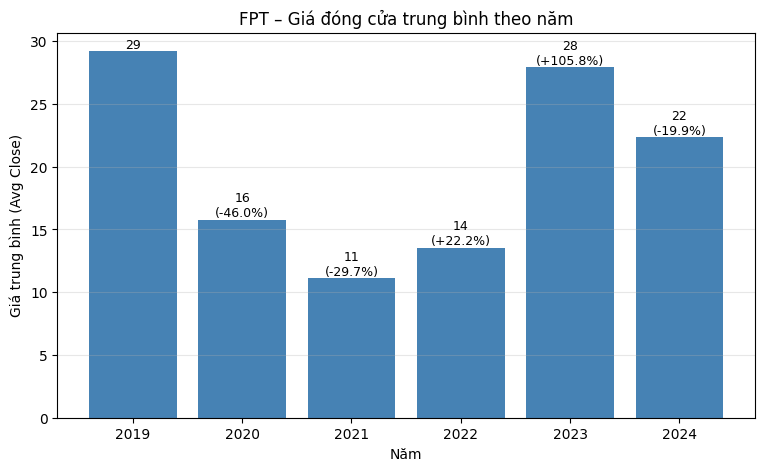

In [28]:
# === CÂU 1: Giá đóng cửa trung bình theo từng năm (Average Close per Year) ===
import matplotlib.pyplot as plt
import pandas as pd

# Giả sử df có cột 'Date' và 'Close'
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Tính giá trung bình theo năm và % thay đổi so với năm trước
annual_avg = (
    df.groupby('Year')['Close']
    .mean()
    .reset_index(name='Avg_Close')
)
annual_avg['Pct_Change'] = annual_avg['Avg_Close'].pct_change() * 100

# --- Vẽ biểu đồ cột ---
plt.figure(figsize=(9,5))
plt.bar(annual_avg['Year'], annual_avg['Avg_Close'], color='steelblue')
plt.title("FPT – Giá đóng cửa trung bình theo năm", fontsize=12)
plt.xlabel("Năm")
plt.ylabel("Giá trung bình (Avg Close)")
plt.grid(axis='y', alpha=0.3)

# --- Ghi nhãn giá trị và % thay đổi lên đầu cột ---
for year, value, pct in zip(annual_avg['Year'], annual_avg['Avg_Close'], annual_avg['Pct_Change']):
    if pd.notna(pct):
        label = f"{value:,.0f}\n({pct:+.1f}%)"
    else:
        label = f"{value:,.0f}"
    plt.text(year, value, label, ha='center', va='bottom', fontsize=9)

plt.show()


 Thống kê lợi suất hằng ngày (Daily Returns):
- Trung bình (Mean): 0.273%
- Độ lệch chuẩn (Volatility): 6.767%
- Skew (Độ lệch): 1.501
- Kurtosis (Độ nhọn): 54.169


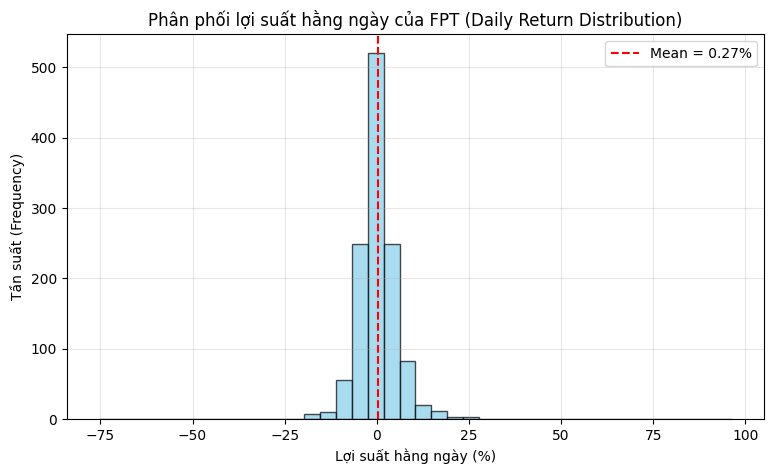

In [31]:
# === CÂU 2: Phân phối lợi suất hằng ngày (Daily Returns) ===
import pandas as pd
import matplotlib.pyplot as plt

# Sao chép dữ liệu gốc
df_return = df.copy()

# Tính lợi suất hằng ngày (%)
df_return['Daily_Return'] = df_return['Close'].pct_change() * 100

# Loại bỏ giá trị NaN đầu tiên
returns = df_return['Daily_Return'].dropna()

# === Tính các thống kê cơ bản ===
mean_ret = returns.mean()
std_ret = returns.std()
skew_ret = returns.skew()
kurt_ret = returns.kurt()

print(" Thống kê lợi suất hằng ngày (Daily Returns):")
print(f"- Trung bình (Mean): {mean_ret:.3f}%")
print(f"- Độ lệch chuẩn (Volatility): {std_ret:.3f}%")
print(f"- Skew (Độ lệch): {skew_ret:.3f}")
print(f"- Kurtosis (Độ nhọn): {kurt_ret:.3f}")

# === Vẽ biểu đồ phân phối (Histogram) ===
plt.figure(figsize=(9,5))
plt.hist(returns, bins=40, color='skyblue', edgecolor='black', alpha=0.7)

# Vẽ đường trung bình
plt.axvline(mean_ret, color='red', linestyle='--', linewidth=1.5, label=f"Mean = {mean_ret:.2f}%")

plt.title("Phân phối lợi suất hằng ngày của FPT (Daily Return Distribution)", fontsize=12)
plt.xlabel("Lợi suất hằng ngày (%)")
plt.ylabel("Tần suất (Frequency)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

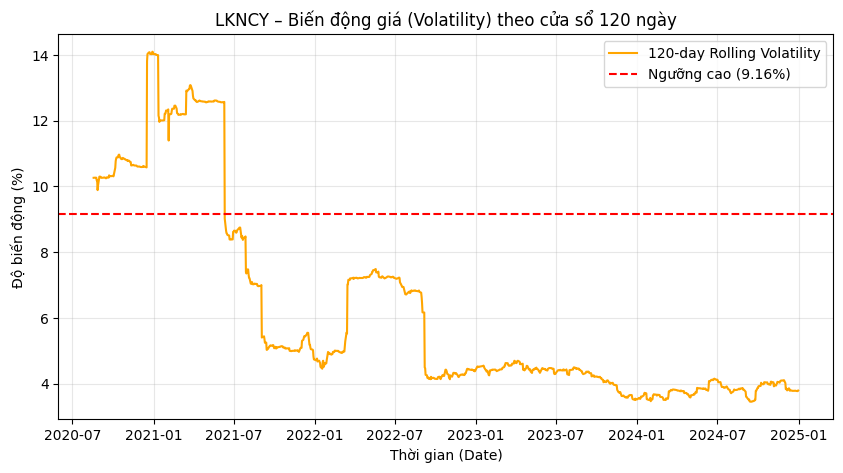

In [35]:
# === CÂU 3: Độ biến động (Volatility) theo thời gian ===
# Giả sử df đã có cột 'Date' và 'Close'
df_vol = df.copy()

# Tính lợi suất hằng ngày (%)
df_vol['Daily_Return'] = df_vol['Close'].pct_change() * 100

# Dùng cửa sổ trượt (rolling window) để tính độ lệch chuẩn (volatility)
window = 120
df_vol['Rolling_Volatility'] = df_vol['Daily_Return'].rolling(window=window).std()

# --- Vẽ biểu đồ ---
plt.figure(figsize=(10,5))
plt.plot(df_vol['Date'], df_vol['Rolling_Volatility'], color='orange', label=f'{window}-day Rolling Volatility')
plt.title(f"LKNCY – Biến động giá (Volatility) theo cửa sổ {window} ngày", fontsize=12)
plt.xlabel("Thời gian (Date)")
plt.ylabel("Độ biến động (%)")
plt.grid(alpha=0.3)

# Đánh dấu vùng biến động cao (ngưỡng)
threshold = df_vol['Rolling_Volatility'].mean() + df_vol['Rolling_Volatility'].std()
plt.axhline(threshold, color='red', linestyle='--', label=f'Ngưỡng cao ({threshold:.2f}%)')

plt.legend()
plt.show()



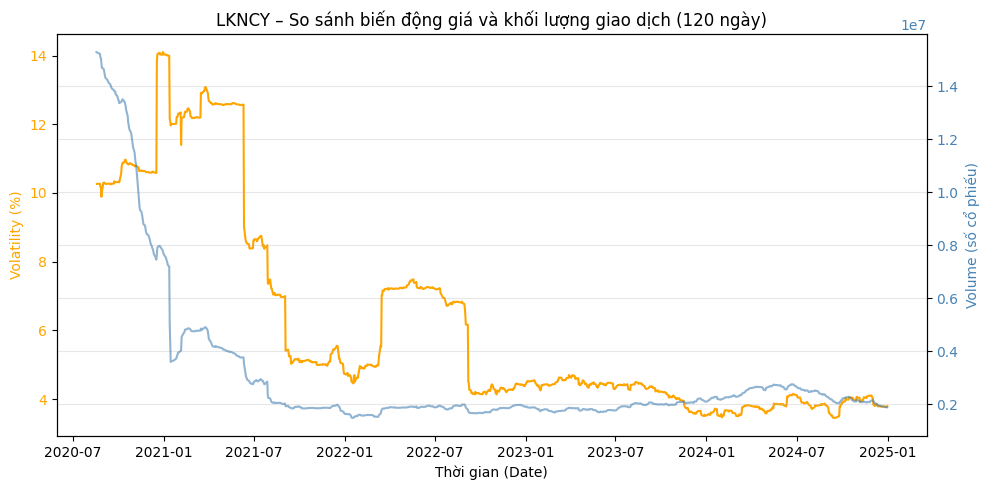

 Hệ số tương quan giữa Volatility và Volume: 0.187
→ Mối quan hệ yếu: biến động giá không gắn chặt với khối lượng.


In [37]:
# === CÂU 4: Mối quan hệ giữa biến động giá (Volatility) và khối lượng giao dịch (Volume) ===

# Sao chép dữ liệu
df_corr = df.copy()

# Tính lợi suất hằng ngày (%)
df_corr['Daily_Return'] = df_corr['Close'].pct_change() * 100

# Tính độ biến động (rolling std của Daily_Return)
window = 120
df_corr['Volatility'] = df_corr['Daily_Return'].rolling(window=window).std()

# Tính khối lượng trung bình trượt
df_corr['Volume_MA'] = df_corr['Volume'].rolling(window=window).mean()

# --- Biểu đồ song song (2 trục Y) ---
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_title(f"LKNCY – So sánh biến động giá và khối lượng giao dịch ({window} ngày)", fontsize=12)
ax1.set_xlabel("Thời gian (Date)")
ax1.set_ylabel("Volatility (%)", color='orange')

ax1.plot(df_corr['Date'], df_corr['Volatility'], color='orange', label='Volatility')
ax1.tick_params(axis='y', labelcolor='orange')

# Trục Y thứ hai cho Volume
ax2 = ax1.twinx()
ax2.set_ylabel("Volume (số cổ phiếu)", color='steelblue')
ax2.plot(df_corr['Date'], df_corr['Volume_MA'], color='steelblue', alpha=0.6, label='Volume (MA)')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Vẽ lưới và hiển thị
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

# --- Phân tích tương quan ---
corr_value = df_corr[['Volatility','Volume']].corr().iloc[0,1]

print(f" Hệ số tương quan giữa Volatility và Volume: {corr_value:.3f}")
if corr_value > 0.5:
    print("→ Mối quan hệ mạnh: khi giá biến động, khối lượng cũng tăng (có thể đầu cơ).")
elif corr_value > 0.2:
    print("→ Mối quan hệ vừa phải: khối lượng có xu hướng tăng khi giá dao động.")
else:
    print("→ Mối quan hệ yếu: biến động giá không gắn chặt với khối lượng.")



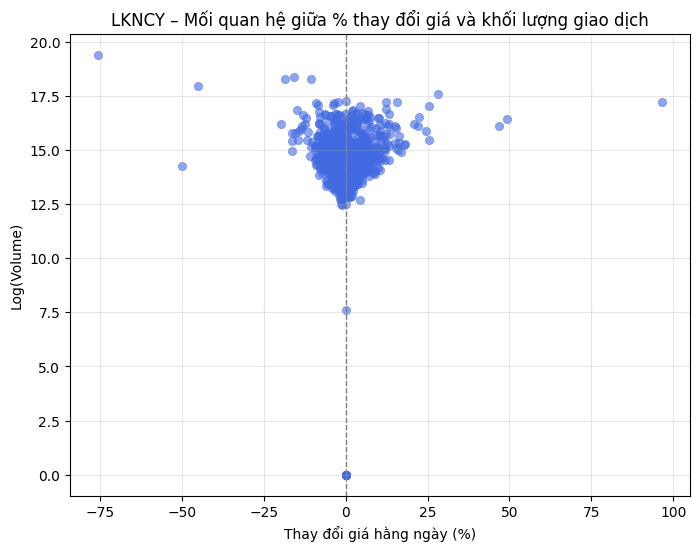

 Hệ số tương quan giữa thay đổi giá và khối lượng: -0.247

 Nhận xét:
→ Mối quan hệ ngược chiều: khi giá tăng, khối lượng giảm (dòng tiền thận trọng).


In [39]:
# === CÂU 5: Phân tích mối quan hệ giữa Giá và Khối lượng (Price–Volume Relationship) ===

# Sao chép dữ liệu
df_pv = df.copy()

# Tính % thay đổi giá đóng cửa (Close)
df_pv['Price_Change'] = df_pv['Close'].pct_change() * 100

# Tính log(Volume) để thu nhỏ thang đo (tránh bị lệch trục)
df_pv['Log_Volume'] = np.log1p(df_pv['Volume'])  # log(1 + Volume)

# Loại bỏ các giá trị NaN đầu tiên
df_pv = df_pv.dropna(subset=['Price_Change', 'Log_Volume'])

# --- Vẽ biểu đồ tán xạ ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Price_Change', 
    y='Log_Volume', 
    data=df_pv, 
    color='royalblue', 
    alpha=0.6, 
    edgecolor=None
)
plt.title("LKNCY – Mối quan hệ giữa % thay đổi giá và khối lượng giao dịch", fontsize=12)
plt.xlabel("Thay đổi giá hằng ngày (%)")
plt.ylabel("Log(Volume)")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(alpha=0.3)
plt.show()

# --- Tính hệ số tương quan ---
corr_val = df_pv[['Price_Change', 'Volume']].corr().iloc[0,1]
print(f" Hệ số tương quan giữa thay đổi giá và khối lượng: {corr_val:.3f}")

# --- Nhận xét gợi ý ---
print("\n Nhận xét:")
if corr_val > 0.5:
    print("→ Mối quan hệ mạnh: khi giá tăng, khối lượng thường tăng (dòng tiền đầu cơ hoặc hưng phấn).")
elif corr_val > 0.2:
    print("→ Mối quan hệ vừa phải: giá và khối lượng có xu hướng cùng chiều nhẹ.")
elif corr_val < -0.2:
    print("→ Mối quan hệ ngược chiều: khi giá tăng, khối lượng giảm (dòng tiền thận trọng).")
else:
    print("→ Mối quan hệ yếu: khối lượng không phản ứng mạnh với biến động giá.")




# Tạo thêm các feature

In [ ]:
# Đọc file df_clean 
f = pd.read_csv('df_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop= True)

CLOSE, OPEN, HIGH, LOW, VOL = 'Close', 'Open', 'High', 'Low', 'Volume'

df['intraday_range'] = df[HIGH] - df[LOW]
df['return'] = df['return'] if 'return' in df.columns else df['Close'].pct_change()
df['volatility_120'] = df['return'].rolling(120, min_periods=120).std()
# 1) Daily returns

df['return'] = df[CLOSE].pct_change()
df['log_return'] = np.log(df[CLOSE] / df[CLOSE].shift(1))
df['range_pct'] = (df['High'] - df['Low']) / df['Close']     # biên độ %
df['close_open_ret'] = (df['Close'] - df['Open']) / df['Open']

# 2) các thống kê rolling (60 ngày liên tiếp )  cột  (volume , return)
win = 120
df['vol_mean'] = df['Volume'].rolling(win).mean()
df['vol_std']  = df['Volume'].rolling(win).std()
df['ret_mean'] = df['return'].rolling(win).mean()
df['ret_std']  = df['return'].rolling(win).std()

df['vol_z'] = (df['Volume'] - df['vol_mean']) / df['vol_std']
df['ret_z'] = (df['return'] - df['ret_mean']) / df['ret_std']

# 3) Tỉ lệ khối lượng so với trung bình (Volume ratio )
df['vol_ratio'] = df['Volume'] / df['Volume'].rolling(30).mean()

# 4)  MA – Moving Average

df['MA_5']  = df['Close'].rolling(5).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

# 5) RSI (14)

delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 6) Bollinger Bands (20, 2σ)

ma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = ma20 + 2 * std20
df['BB_lower'] = ma20 - 2 * std20
df['BB_pos'] = (df['Close'] - ma20) / (2 * std20)  # vị trí giá trong dải BB

# 7) MACD (12, 26, 9)

ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_line']   = ema12 - ema26
df['MACD_signal'] = df['MACD_line'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD_line'] - df['MACD_signal']

# 8) ATR (14)

tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift(1)).abs(),
    (df['Low']  - df['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean()

# 9 ) Chuẩn hóa z-score

for col in ['return','vol_ratio','range_pct','RSI_14']:
    df[col + '_z'] = (df[col] - df[col].rolling(120).mean()) / df[col].rolling(120).std()





 Xử lý NaN & xuất file

In [17]:
df_feat = df.dropna().reset_index(drop=True)
df_feat.to_csv('df_feat.csv', index=False)
print('write file "df_feat" success')

write file "df_feat" success


# Phát hiện bất thường theo các quy tắc 

1) Rule-based

In [41]:
import numpy as np
import pandas as pd

df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# MA30 của Volume
ma30_vol = df['Volume'].rolling(30, min_periods=30).mean()

# --- 1) Luật (nhạy hơn) ---
df['flag_vol_return'] = (df['vol_ratio'] > 2.5) & (df['return'].abs() > 0.03)

# Vượt BB_upper 1% + Volume > 2 x MA30
df['flag_bollinger'] = (df['Close'] > df['BB_upper'] * 1.005) & (df['Volume'] > 1.5 * ma30_vol)

# --- 2) Z-band nhẹ tay hơn ---
abs_ret_z = df['ret_z'].abs()
vol_z = df['vol_z']

cond_high = ((abs_ret_z >= 2.2) | (vol_z >= 2.2)) & (df['close_open_ret'].abs() >= 0.02)
cond_med  = ((abs_ret_z.between(1.5, 2.2, inclusive='left')) |
             (vol_z.between(1.5, 2.2, inclusive='left')) |
             (df['intraday_range'] >= 0.02))
cond_low  = ((abs_ret_z.between(1.0, 1.5, inclusive='left')) |
             (vol_z.between(1.0, 1.5, inclusive='left')))

df['z_band'] = 'None'
df.loc[cond_low,  'z_band'] = 'Low'
df.loc[cond_med,  'z_band'] = 'Medium'
df.loc[cond_high, 'z_band'] = 'High'

# --- 3) Điểm rule_score (chuẩn hóa 1.2→2.5) ---
z_star = np.maximum(abs_ret_z, vol_z)
df['z_intensity'] = np.clip((z_star - 1.2) / (2.5 - 1.2), 0, 1)

df['binary_flags'] = (df['flag_vol_return'].astype(int) + df['flag_bollinger'].astype(int)) / 2.0

# Nhấn mạnh cờ boole để tăng độ nhạy
df['rule_score'] = 0.5 * df['z_intensity'] + 0.5 * df['binary_flags']

# (tuỳ chọn) cộng bonus nhỏ nếu có ít nhất 1 cờ
bonus = 0.1 * ((df['binary_flags'] > 0).astype(float))
df['rule_score'] = np.clip(df['rule_score'] + bonus, 0, 1)

cols_keep = [
    'Date','return','vol_ratio','ret_z','vol_z','intraday_range','close_open_ret',
    'flag_vol_return','flag_bollinger','z_band','z_intensity','binary_flags','rule_score'
]
df_rule = df[cols_keep].copy()
df_rule.to_csv("df_rule.csv", index=False)

print("Stage 3 (nhạy hơn)  -> df_rule.csv")
print(df_rule.tail(3))



Stage 3 (nhạy hơn)  -> df_rule.csv
           Date    return  vol_ratio     ret_z     vol_z  intraday_range  \
1217 2024-12-27  0.001245   0.464741 -0.023557 -0.716056        0.200001   
1218 2024-12-30  0.020730   1.053262  0.494446 -0.226316        0.620001   
1219 2024-12-31  0.042648   1.037819  1.059807 -0.215893        1.699999   

      close_open_ret  flag_vol_return  flag_bollinger  z_band  z_intensity  \
1217        0.002911            False           False  Medium          0.0   
1218        0.025833            False           False  Medium          0.0   
1219        0.031338            False           False  Medium          0.0   

      binary_flags  rule_score  
1217           0.0         0.0  
1218           0.0         0.0  
1219           0.0         0.0  


PHÁT HIỆN BẤT THƯỜNG BẰNG ML (UNSUPERVISED)

In [19]:
# --- 1. Load dữ liệu đặc trưng ---
df = pd.read_csv("df_feat.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# --- 2. Chọn các biến đưa vào mô hình ---
features = [
    'log_return', 'vol_ratio', 'range_pct', 'RSI_14',
    'ret_z', 'vol_z', 'volatility_120', 'MACD_hist', 'BB_pos', 'ATR_14'
]

X = df[features].dropna().values

# --- 3. Huấn luyện IsolationForest ---
iso = IsolationForest(
    n_estimators=500,
    contamination=0.03,     # tỉ lệ dự kiến điểm bất thường
    random_state=42
)
iso.fit(X)

# --- 4. Tính điểm bất thường (ml_score) ---
# decision_function: càng lớn = càng bình thường → đảo dấu & chuẩn hoá về [0,1]
raw = -iso.decision_function(X).reshape(-1, 1)
scaler = MinMaxScaler()
df['ml_score'] = scaler.fit_transform(raw)

# --- 5. Xuất kết quả ---
df.to_csv("df_ml.csv", index=False)
print(" Đã tạo cột ml_score trong df_ml.csv")
print(df[['Date', 'ml_score']].tail(10))

 Đã tạo cột ml_score trong df_ml.csv
           Date  ml_score
1210 2024-12-17  0.034084
1211 2024-12-18  0.069947
1212 2024-12-19  0.042128
1213 2024-12-20  0.070559
1214 2024-12-23  0.016500
1215 2024-12-24  0.057924
1216 2024-12-26  0.063827
1217 2024-12-27  0.064420
1218 2024-12-30  0.074674
1219 2024-12-31  0.134881


# Ensemble & Gán nhãn

In [40]:
# --- 1. Load dữ liệu ---
df_rule = pd.read_csv("df_rule.csv")   
df_ml   = pd.read_csv("df_ml.csv")     

# Gộp theo Date (tránh lỗi lệch chỉ số)
df_final = pd.merge(df_ml, df_rule[['Date', 'rule_score']], on='Date', how='left')

# --- 2. Ensemble score ---
df_final['anomaly_score'] = 0.7 * df_final['ml_score'] + 0.3 * df_final['rule_score']

# --- 3. Label Yes/No ---
df_final['label'] = np.where(df_final['anomaly_score'] >= 0.4, 'Yes', 'No')

# --- 4. Severity ---
def classify_severity(row):
    abs_ret_z = abs(row.get('ret_z', 0))
    vol_z = row.get('vol_z', 0)
    score = row['anomaly_score']

    if (abs_ret_z >= 3.5) or (vol_z >= 3.5) or (score >= 0.8):
        return 'High'
    elif (0.6 <= score < 0.8) or (2 <= abs_ret_z < 3) or (2 <= vol_z < 3.5):
        return 'Medium'
    elif (0.5 <= score < 0.6) or (1.5 <= abs_ret_z < 2) or (1.5 <= vol_z < 2):
        return 'Low'
    else:
        return 'Normal'

df_final['severity'] = df_final.apply(classify_severity, axis=1)

# --- 5. Xuất kết quả cuối ---
cols_export = ['Date', 'anomaly_score', 'label', 'severity']
df_final.to_csv("df_final_output.csv", index=False)

print(" File  df_final_output.csv   đã tạo")
print(df_final[cols_export].tail(10))


 File  df_final_output.csv   đã tạo
            Date  anomaly_score label severity
1210  2024-12-17       0.023859    No   Normal
1211  2024-12-18       0.048963    No   Normal
1212  2024-12-19       0.029489    No   Normal
1213  2024-12-20       0.049391    No   Normal
1214  2024-12-23       0.011550    No   Normal
1215  2024-12-24       0.040546    No   Normal
1216  2024-12-26       0.044679    No   Normal
1217  2024-12-27       0.045094    No   Normal
1218  2024-12-30       0.052271    No   Normal
1219  2024-12-31       0.094417    No   Normal


# Gom cụm bất thường & pump-dump

In [21]:

# --- 1) Load dữ liệu ---
final = pd.read_csv("df_final_output.csv")   
feat  = pd.read_csv("df_feat.csv")           

# Đảm bảo Date chuẩn datetime
final['Date'] = pd.to_datetime(final['Date'])
feat['Date']  = pd.to_datetime(feat['Date'])

# Nếu file final không có Close thì merge thêm từ feat
if 'Close' not in final.columns:
    final = pd.merge(final, feat[['Date', 'Close', 'return', 'ret_z', 'vol_z']], on='Date', how='left')
else:
    # Merge thêm các cột còn thiếu (ret_z, vol_z, return)
    if 'ret_z' not in final.columns or 'vol_z' not in final.columns:
        final = pd.merge(final, feat[['Date', 'return', 'ret_z', 'vol_z']], on='Date', how='left')

# --- 2) Tính post_1d / 3d / 5d ---
for n in (1, 3, 5):
    final[f'Close_f{n}'] = final['Close'].shift(-n)
    final[f'post_{n}d']  = (final[f'Close_f{n}'] / final['Close'] - 1.0) * 100.0

# --- 3) Tạo cluster cho label = "Yes" (gap ≤ 1 ngày) ---
yes = final[final['label'] == 'Yes'].copy()
yes['diff_days'] = yes['Date'].diff().dt.days
yes['new_cluster'] = (yes['diff_days'].isna()) | (yes['diff_days'] > 2)
yes['cluster_id'] = yes['new_cluster'].cumsum()

clusters = []
for cid, block in yes.groupby('cluster_id'):
    start_date = block['Date'].iloc[0]
    end_date   = block['Date'].iloc[-1]
    length_days = (end_date - start_date).days + 1

    n_high_days = (block['severity'] == 'High').sum()
    max_vol_z = block['vol_z'].max()
    avg_ret = block['return'].mean() * 100

    # post_xd từ END
    end_idx = block.index[-1]
    post_1d = final.loc[end_idx, 'post_1d']
    post_3d = final.loc[end_idx, 'post_3d']
    post_5d = final.loc[end_idx, 'post_5d']

    # --- 4) Pump–Dump check ---
    pump_dump = 0
    pump_pct = dump_pct = time_to_peak = time_to_dump = np.nan

    # Chỉ kiểm tra nếu trong cụm có vol_z ≥ 2
    if (block['vol_z'] >= 2).any():
        peak_idx = block['Close'].idxmax()
        peak_close = block.loc[peak_idx, 'Close']
        start_close = block['Close'].iloc[0]

        pump_pct = (peak_close / start_close - 1) * 100
        time_to_peak = (block.loc[block['Close'].idxmax(), 'Date'] - start_date).days

        # Tìm dump trong 3 ngày sau peak
        look = final.loc[peak_idx + 1 : peak_idx + 3].copy()
        if not look.empty:
            min_close = look['Close'].min()
            dump_pct = (min_close / peak_close - 1) * 100
            time_to_dump = (look.loc[look['Close'].idxmin(), 'Date'] - block.loc[peak_idx, 'Date']).days
            if dump_pct <= -5:
                pump_dump = 1

    clusters.append({
        'cluster_id': cid,
        'start_date': start_date.date(),
        'end_date': end_date.date(),
        'length_days': length_days,
        'n_high_days': n_high_days,
        'max_vol_z': max_vol_z,
        'avg_ret_%': avg_ret,
        'post_1d_%': post_1d,
        'post_3d_%': post_3d,
        'post_5d_%': post_5d,
        'pump_dump': pump_dump,
        'pump_pct_%': pump_pct,
        'dump_pct_%': dump_pct,
        'time_to_peak_days': time_to_peak,
        'time_to_dump_days': time_to_dump
    })

# --- 5) Xuất kết quả ---
clusters_df = pd.DataFrame(clusters)
clusters_df.to_csv("clusters.csv", index=False)

print("File clusters.csv đã được tạo thành công.")
print(clusters_df.head())


File clusters.csv đã được tạo thành công.
   cluster_id  start_date    end_date  length_days  n_high_days  max_vol_z  \
0           1  2019-11-13  2019-11-15            3            2   6.586924   
1           2  2019-11-18  2019-11-18            1            1   5.801258   
2           3  2019-11-21  2019-11-22            2            1   3.045664   
3           4  2020-01-08  2020-01-10            3            3   4.455720   
4           5  2020-01-13  2020-01-13            1            0   1.836709   

   avg_ret_%  post_1d_%  post_3d_%  post_5d_%  pump_dump  pump_pct_%  \
0  19.253710   4.219095  -2.664697  10.473723          0   25.908675   
1   4.219095  -3.196021  -0.745735  13.636364          1    0.000000   
2   6.535811   7.202679   5.427132   1.306531          0    6.797852   
3   7.488715   5.955683   4.178212  15.466299          0   12.442980   
4   5.955683  -0.217870   5.729841   3.834419          0         NaN   

   dump_pct_%  time_to_peak_days  time_to_dump_days  
0 

# Kiểm định và giảm nhiễu

In [22]:
# === Stage 7: Validation & Noise Reduction ===
import pandas as pd
import numpy as np

# --- 1. Load dữ liệu cần thiết ---
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])

# --- 2. SENSITIVITY TEST ---
# Thử các ngưỡng z khác nhau để xem số ngày bất thường thay đổi thế nào
sensitivity = []
for z_th in [2.5, 3.0, 3.5]:
    subset = df[(df['ret_z'].abs() >= z_th) | (df['vol_z'] >= z_th)]
    sensitivity.append({
        'z_threshold': z_th,
        'n_detected_days': len(subset),
        'ratio_detected_%': len(subset) / len(df) * 100
    })
sensitivity_df = pd.DataFrame(sensitivity)

# --- 3. BOOTSTRAP / PERMUTATION TEST ---
np.random.seed(42)
n = len(df)
actual_detected = (df['label'] == 'Yes').sum()
simulations = []

for _ in range(1000):
    shuffled = np.random.permutation(df['anomaly_score'])
    random_yes = (shuffled > 0.5).sum()
    simulations.append(random_yes)

p_value = np.mean(np.array(simulations) >= actual_detected)

# --- 4. MARKET COMPARISON (tùy chọn) ---
# Nếu bạn chưa có file thị trường (index.csv), đoạn này tự bỏ qua
try:
    market = pd.read_csv("index.csv")
    market['Date'] = pd.to_datetime(market['Date'])
    market['index_ret'] = market['Close'].pct_change()
    merged = pd.merge(df, market[['Date','index_ret']], on='Date', how='left')
    merged['market_spike'] = (merged['index_ret'].abs() > 0.03)
    market_overlap = merged[(merged['label']=="Yes") & (merged['market_spike'])].shape[0]
    market_adjusted = actual_detected - market_overlap
    market_comment = f"{market_overlap} anomalies coincide with market-wide moves (|index_ret|>3%)"
except FileNotFoundError:
    market_overlap = np.nan
    market_adjusted = np.nan
    market_comment = "No index.csv provided – skipped market comparison"

# --- 5. Tổng hợp kết quả kiểm định ---
validation_summary = {
    'total_days': len(df),
    'total_anomalies': int(actual_detected),
    'p_value_bootstrap': round(p_value, 4),
    'market_overlap': market_overlap,
    'market_adjusted_anomalies': market_adjusted,
    'market_comment': market_comment,
    'note': "Lower p-value (<0.05) → model anomalies unlikely to occur by chance."
}

summary_df = pd.DataFrame([validation_summary])
summary_df.to_csv("validation_summary.csv", index=False)

print(" File  validation_summary.csv  đã được tạo.")
print(summary_df)
print("\n--- Sensitivity test ---")
print(sensitivity_df)


 File  validation_summary.csv  đã được tạo.
   total_days  total_anomalies  p_value_bootstrap  market_overlap  \
0        1220               77                0.0             NaN   

   market_adjusted_anomalies  \
0                        NaN   

                                      market_comment  \
0  No index.csv provided – skipped market comparison   

                                                note  
0  Lower p-value (<0.05) → model anomalies unlike...  

--- Sensitivity test ---
   z_threshold  n_detected_days  ratio_detected_%
0          2.5               57          4.672131
1          3.0               38          3.114754
2          3.5               23          1.885246


# Trực quan hóa

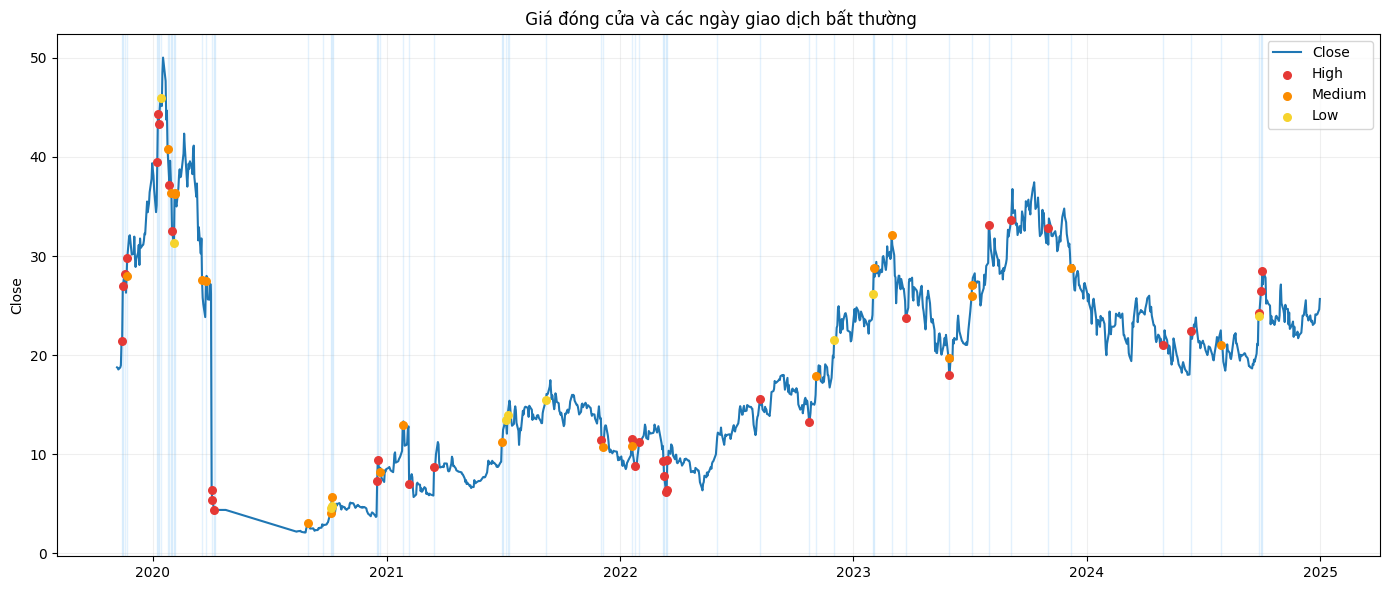

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============== Load data ==============
df = pd.read_csv("df_final_output.csv")
clu = pd.read_csv("clusters.csv") if True else pd.DataFrame()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Helpers
def severity_color(s):
    if s == 'High': return '#e53935'   # red
    if s == 'Medium': return '#fb8c00' # orange
    if s == 'Low': return '#f6d32d'    # yellow
    return '#9e9e9e'                   # grey for Normal

# ============== 1) Price + anomaly marks + cluster shading ==============
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(df['Date'], df['Close'], lw=1.5, label='Close')

# Shade clusters if available
if not clu.empty:
    clu['start_date'] = pd.to_datetime(clu['start_date'])
    clu['end_date']   = pd.to_datetime(clu['end_date'])
    for _, r in clu.iterrows():
        ax.axvspan(r['start_date'], r['end_date'], color='#90caf9', alpha=0.25)

# Mark anomalies by severity
for sev in ['High','Medium','Low']:
    m = (df['label']=='Yes') & (df['severity']==sev)
    ax.scatter(df.loc[m,'Date'], df.loc[m,'Close'], s=30, color=severity_color(sev), label=sev, zorder=3)

ax.set_title(' Giá đóng cửa và các ngày giao dịch bất thường')
ax.set_ylabel('Close')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig('fig_price_anomalies.png', dpi=150)




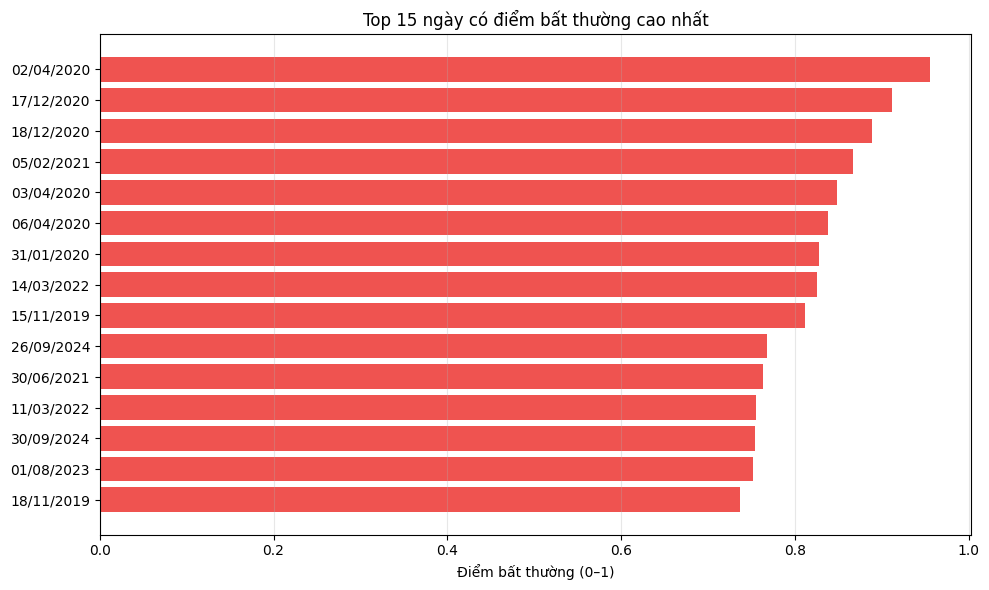

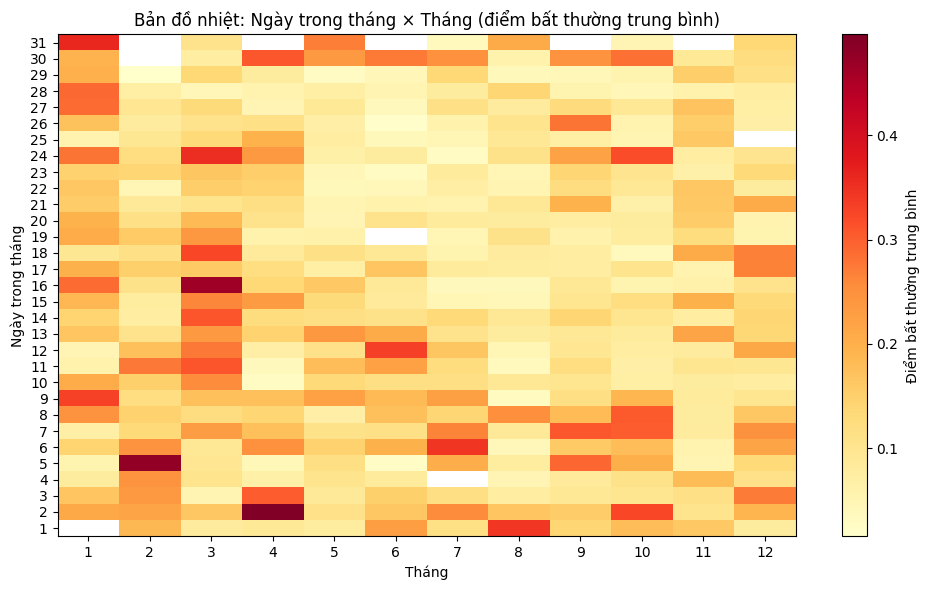

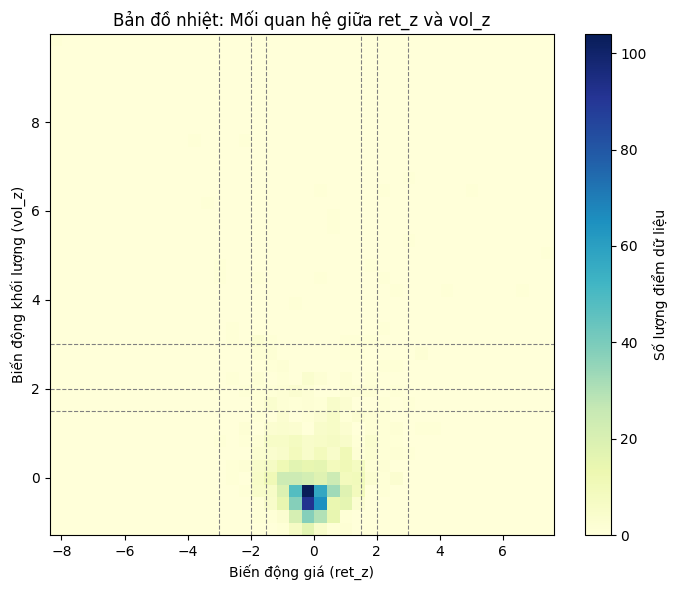

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============= Nạp dữ liệu =============
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Thử nạp file cụm
try:
    clu = pd.read_csv("clusters.csv")
    has_clusters = True
except FileNotFoundError:
    clu = pd.DataFrame()
    has_clusters = False


# ============= 3) Biểu đồ cột ngang: Top 15 ngày bất thường nhất =============
topn = (df.sort_values('anomaly_score', ascending=False)
          .head(15)
          .sort_values('anomaly_score'))
labels = topn['Date'].dt.strftime('%d/%m/%Y')

plt.figure(figsize=(10,6))
plt.barh(labels, topn['anomaly_score'].values, color='#ef5350')
plt.title('Top 15 ngày có điểm bất thường cao nhất')
plt.xlabel('Điểm bất thường (0–1)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_top15_ngay.png', dpi=150)
plt.show()

# ============= 4) Heatmap lịch: Ngày trong tháng × Tháng =============
cal = df.copy()
cal['Tháng'] = cal['Date'].dt.month
cal['Ngày']   = cal['Date'].dt.day
pivot = cal.pivot_table(index='Ngày', columns='Tháng', values='anomaly_score', aggfunc='mean')

plt.figure(figsize=(10,6))
plt.imshow(pivot.values, aspect='auto', origin='lower', cmap='YlOrRd')
plt.colorbar(label='Điểm bất thường trung bình')
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.title('Bản đồ nhiệt: Ngày trong tháng × Tháng (điểm bất thường trung bình)')
plt.xlabel('Tháng'); plt.ylabel('Ngày trong tháng')
plt.tight_layout()
plt.savefig('heatmap_lich_bat_thuong.png', dpi=150)
plt.show()

# ============= 5) Heatmap 2D: ret_z vs vol_z =============
x = df['ret_z'].values
y = df['vol_z'].values

plt.figure(figsize=(7,6))
plt.hist2d(x, y, bins=40, cmap='YlGnBu')
plt.colorbar(label='Số lượng điểm dữ liệu')
for thr in [1.5, 2, 3]:
    plt.axvline(thr, ls='--', lw=0.8, color='gray')
    plt.axvline(-thr, ls='--', lw=0.8, color='gray')
    plt.axhline(thr, ls='--', lw=0.8, color='gray')
plt.xlabel('Biến động giá (ret_z)')
plt.ylabel('Biến động khối lượng (vol_z)')
plt.title('Bản đồ nhiệt: Mối quan hệ giữa ret_z và vol_z')
plt.tight_layout()
plt.savefig('heatmap_retZ_volZ.png', dpi=150)
plt.show()




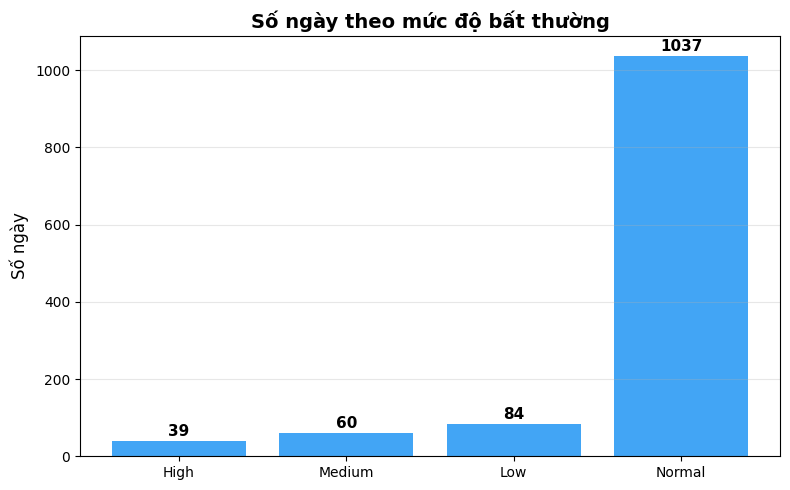

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Nạp dữ liệu
df = pd.read_csv("df_final_output.csv")

# Tính số lượng từng mức độ
severity_counts = df['severity'].value_counts().reindex(['High','Medium','Low','Normal'], fill_value=0)

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(severity_counts.index, severity_counts.values, color='#42a5f5')

# Thêm nhãn số lên trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tiêu đề và nhãn trục
plt.title('Số ngày theo mức độ bất thường', fontsize=14, fontweight='bold')
plt.ylabel('Số ngày', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bieudo_muc_do_bat_thuong.png', dpi=150)
plt.show()


In [42]:
import pandas as pd
import numpy as np

# === 1. Nạp dữ liệu chính ===
df = pd.read_csv("df_final_output.csv")
df['Date'] = pd.to_datetime(df['Date'])
total_days = len(df)

# === 2. Thống kê số ngày bất thường ===
abnormal_df = df[df['label'] == 'Yes']
n_abnormal = len(abnormal_df)
pct_abnormal = n_abnormal / total_days * 100

# === 3. Đếm theo mức độ ===
sev_counts = abnormal_df['severity'].value_counts().reindex(['High','Medium','Low'], fill_value=0)
high_n, med_n, low_n = sev_counts['High'], sev_counts['Medium'], sev_counts['Low']

# === 4. Xác định loại bất thường (giá, khối lượng, hay cả hai) ===
def detect_type(row):
    cond_price = abs(row.get('ret_z',0)) >= 2
    cond_vol   = row.get('vol_z',0) >= 2
    if cond_price and cond_vol: return "Giá + Khối lượng"
    elif cond_price: return "Giá"
    elif cond_vol: return "Khối lượng"
    else: return "Bình thường"

df['loai_bat_thuong'] = df.apply(detect_type, axis=1)

# === 5. Đếm số ngày liên tiếp có label Yes (để giống cột “so_ngay_lien_tiep”) ===
df = df.sort_values('Date').reset_index(drop=True)
df['group'] = (df['label'] != df['label'].shift()).cumsum()
df['so_ngay_lien_tiep'] = df.groupby('group')['label'].transform(lambda x: len(x) if x.iloc[0]=='Yes' else 0)

# === 6. Tạo bảng tóm tắt dạng giống hình bạn gửi ===
table = df[df['label']=='Yes'][['Date','loai_bat_thuong','severity','so_ngay_lien_tiep']].copy()
table.rename(columns={'severity':'anomaly_level'}, inplace=True)
table.reset_index(inplace=True)
table.index.name = 'Ticker'

# === 7. In ra kết quả ===
print("BẢNG KẾT QUẢ THỐNG KÊ CÁC NGÀY BẤT THƯỜNG")
print(f"Tổng số ngày bất thường: {n_abnormal} ({pct_abnormal:.2f}% dữ liệu)\n")
display(table.head(10))

print("\nTỔNG HỢP BẤT THƯỜNG:")
print(f"- Tổng số ngày bất thường: {n_abnormal}")
print(f"   • High  : {high_n} ngày")
print(f"   • Medium: {med_n} ngày")
print(f"   • Low   : {low_n} ngày")
print(f"- Tỷ lệ ngày bất thường: {pct_abnormal:.2f}% trên toàn bộ dữ liệu")

# === 8. Kết luận sơ bộ ===
if high_n > 15 or pct_abnormal > 20:
    conclusion = "Có dấu hiệu thao túng đáng kể."
elif pct_abnormal > 10:
    conclusion = "Có thể có thao túng, cần kiểm tra thêm."
else:
    conclusion = "Chưa phát hiện dấu hiệu thao túng rõ ràng."

print(f"\nKẾT LUẬN: {conclusion}")


BẢNG KẾT QUẢ THỐNG KÊ CÁC NGÀY BẤT THƯỜNG
Tổng số ngày bất thường: 77 (6.31% dữ liệu)



,index,Date,loai_bat_thuong,anomaly_level,so_ngay_lien_tiep
Ticker,,,,,
0,5,2019-11-13,Giá + Khối lượng,High,1
1,7,2019-11-15,Giá + Khối lượng,High,2
2,8,2019-11-18,Khối lượng,High,2
3,11,2019-11-21,Khối lượng,Medium,2
4,12,2019-11-22,Khối lượng,Medium,2
5,42,2020-01-08,Giá + Khối lượng,Medium,4
6,43,2020-01-09,Giá + Khối lượng,High,4
7,44,2020-01-10,Khối lượng,High,4
8,45,2020-01-13,Bình thường,Low,4



TỔNG HỢP BẤT THƯỜNG:
- Tổng số ngày bất thường: 77
   • High  : 25 ngày
   • Medium: 34 ngày
   • Low   : 10 ngày
- Tỷ lệ ngày bất thường: 6.31% trên toàn bộ dữ liệu

KẾT LUẬN: Có dấu hiệu thao túng đáng kể.
